In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

In [71]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.4f}'.format})

# 1 Data load

In [72]:
df = pd.read_csv("student_career_success_dataset.csv")

# variables
Y = df['Employability_Score']
features = ['Study_Hours_Per_Week', 'CGPA', 'Resume_Score']
X = df[features]
X_const = sm.add_constant(X)

df.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.280000000000,Good,9,...,7,8,Advanced,72,231.700000000000,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.530000000000,Poor,6,...,6,5,Basic,59,157.450000000000,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.830000000000,Average,8,...,8,7,Advanced,76,203.450000000000,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.800000000000,Average,5,...,6,6,Intermediate,67,171.500000000000,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.930000000000,Average,9,...,8,9,Advanced,82,225.450000000000,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [73]:
col_y = 'Employability_Score'
cols_x = ['Study_Hours_Per_Week', 'CGPA', 'Resume_Score']

df_clean = df[cols_x + [col_y]].dropna()

display(df_clean.head())

,Study_Hours_Per_Week,CGPA,Resume_Score,Employability_Score
0,21,3.280000000000,100,231.700000000000
1,18,2.530000000000,80,157.450000000000
2,19,2.830000000000,100,203.450000000000
3,19,2.800000000000,85,171.500000000000
4,19,2.930000000000,100,225.450000000000


# 2 Uji asumsi klasik

In [74]:
model = sm.OLS(Y, X_const).fit()
residuals = model.resid
fitted_values = model.fittedvalues
koefisien = model.params

# persamaan regresi
persamaan = f"Y = {koefisien['const']:.4f}"
for variabel in features:
    nilai_beta = koefisien[variabel]
    
    if nilai_beta >= 0:
        persamaan += f" + {nilai_beta:.4f}({variabel})"
    else:
        persamaan += f" - {abs(nilai_beta):.4f}({variabel})"

print(persamaan)

Y = -130.4957 + 0.0066(Study_Hours_Per_Week) + 35.5604(CGPA) + 2.4352(Resume_Score)


## 2.1 Uji linearitas

In [75]:
# uji Ramsey RESET
reset_test = linear_reset(model, power=2, test_type='fitted', use_f=True)

f_stat = reset_test.fvalue
p_value = reset_test.pvalue
df1 = reset_test.df_num
df2 = reset_test.df_denom
alpha = 0.05
f_crit = stats.f.ppf(1 - alpha, df1, df2)

print("Uji Ramsey RESET\n")
print("1. Hipotesis")
print("   H0: Model regresi adalah linear (asumsi linearitas terpenuhi).")
print("   H1: Model regresi mengandung unsur non linear (Asumsi tidak terpenuhi).")

print("\n2. Nilai kritis")
print(f"   Tingkat signifikansi (\u03B1) : {alpha}")
print(f"   Derajat bebas (df1, df2): ({int(df1)}, {int(df2)})")
print(f"   F-Tabel: {f_crit:.4f}")

print("\n3. Statistik uji")
print(f"   F-Hitung: {f_stat:.4f}")
print(f"   P-Value: {p_value:.4f}")

print("\n4. Keputusan:")
if p_value < alpha:
    print(f"   Tolak H0 (Karena P-Value {p_value:.4f} < {alpha} dan F-Hitung > F-Tabel).")
else:
    print(f"   Gagal tolak H0, karena P-Value {p_value:.4f} >= {alpha} dan F-Hitung <= F-Tabel).")
    
print("\n5. Kesimpulan")
if p_value < alpha:
    print("   Asumsi linearitas tidak terpenuhi, terdapat hubungan non-linear pada data.")
else:
    print("   Asumsi linearitas terpenuhi, tidak terdapat hubungan non-linear pada data.")

Uji Ramsey RESET

1. Hipotesis
   H0: Model regresi adalah linear (asumsi linearitas terpenuhi).
   H1: Model regresi mengandung unsur non linear (Asumsi tidak terpenuhi).

2. Nilai kritis
   Tingkat signifikansi (α) : 0.05
   Derajat bebas (df1, df2): (1, 49995)
   F-Tabel: 3.8416

3. Statistik uji
   F-Hitung: 3061.0769
   P-Value: 0.0000

4. Keputusan:
   Tolak H0 (Karena P-Value 0.0000 < 0.05 dan F-Hitung > F-Tabel).

5. Kesimpulan
   Asumsi linearitas tidak terpenuhi, terdapat hubungan non-linear pada data.


## 2.2 Uji normalitas residual

In [76]:
residuals = model.resid

# uji Jarque-Bera
jb_stat, p_value_jb = jarque_bera(residuals)
alpha = 0.05

print("Uji Jarque-Bera\n")
print("1. Hipotesis:")
print("   H0: Residual berdistribusi normal (asumsi terpenuhi).")
print("   H1: Residual tidak berdistribusi normal (asumsi tidak terpenuhi).\n")

print("\n2. Nilai kritis:")
print(f"   Tingkat signifikansi (\u03B1): {alpha}")

print("\n3. Statistik uji")
print(f"   JB-Hitung: {jb_stat:.4f}")
print(f"   P-Value: {p_value_jb:.4f}")

print("\n4. Keputusan")
if p_value_jb < alpha:
    print(f"   Keputusan: Tolak H0, karena P-Value {p_value_jb:.4f} < {alpha}.")
else:
    print(f"   Keputusan: Gagal tolak H0, karena P-Value {p_value_jb:.4f} >= {alpha}.")
print("\n5. Kesimpulan")
if p_value_jb < alpha:
    print("   Residual tidak berdistribusi normal, asumsi normalitas tidak terpenuhi.")
else:
    print("   Residual berdistribusi normal, asumsi normalitas terpenuhi.")

Uji Jarque-Bera

1. Hipotesis:
   H0: Residual berdistribusi normal (asumsi terpenuhi).
   H1: Residual tidak berdistribusi normal (asumsi tidak terpenuhi).


2. Nilai kritis:
   Tingkat signifikansi (α): 0.05

3. Statistik uji
   JB-Hitung: 126.0450
   P-Value: 0.0000

4. Keputusan
   Keputusan: Tolak H0, karena P-Value 0.0000 < 0.05.

5. Kesimpulan
   Residual tidak berdistribusi normal, asumsi normalitas tidak terpenuhi.


## 2.3 Uji heteroskedastisitas

In [77]:
# uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, X_const)
lm_stat = bp_test[0]
p_value = bp_test[1]

df_chi = X.shape[1]
alpha = 0.05
chi2_crit = stats.chi2.ppf(1 - alpha, df_chi)

print("Uji Breusch-Pagan\n")
print("1. Hipotesis")
print("   H0: Varians residual konstan (asumsi homoskedastisitas terpenuhi).")
print("   H1: Varians residual tidak konstan (asumsi homoskedastisitas tidak terpenuhi).")

print("\n2. Nilai kritis")
print(f"   Tingkat signifikansi (\u03B1): {alpha}")
print(f"   Derajat bebas (df): {df_chi}")
print(f"   Chi-Square Tabel: {chi2_crit:.4f}")

print("\n3. Statistik uji")
print(f"   LM-Hitung: {lm_stat:.4f}")
print(f"   P-Value: {p_value:.4f}")

print("\n4. Keputusan")
if p_value < alpha:
    print(f"   Tolak H0, karena P-Value {p_value:.4f} < {alpha} dan LM Hitung > Chi-Square Tabel.")
else:
    print(f"   Gagal tolak H0, karena P-Value {p_value:.4f} >= {alpha} dan LM Hitung <= Chi-Square Tabel.")

print("\n5. Kesimpulan")
if p_value < alpha:
    print("   Terdapat heteroskedastisitas pada model, asumsi tidak terpenuhi.")
else:
    print("Terdapat homoskedastisitas pada model, asumsi terpenuhi.")

Uji Breusch-Pagan

1. Hipotesis
   H0: Varians residual konstan (asumsi homoskedastisitas terpenuhi).
   H1: Varians residual tidak konstan (asumsi homoskedastisitas tidak terpenuhi).

2. Nilai kritis
   Tingkat signifikansi (α): 0.05
   Derajat bebas (df): 3
   Chi-Square Tabel: 7.8147

3. Statistik uji
   LM-Hitung: 192.4713
   P-Value: 0.0000

4. Keputusan
   Tolak H0, karena P-Value 0.0000 < 0.05 dan LM Hitung > Chi-Square Tabel.

5. Kesimpulan
   Terdapat heteroskedastisitas pada model, asumsi tidak terpenuhi.


## 2.4 Uji multikolinearitas

In [78]:
X = df_clean[cols_x]
X_const = sm.add_constant(X)

# VIF untuk setiap variabel
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_const.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif_data_clean = vif_data.iloc[1:].reset_index(drop=True)

print("Uji Asumsi Multikolinearitas\n")
print("Kriteria keputusan:")
print("    VIF < 10 : Tidak terdapat multikolinearitas (asumsi terpenuhi).")
print("    VIF >= 10: Terdapat multikolinearitas (asumsi tidak terpenuhi).\n")

print("Hasil perhitungan VIF:")
print(vif_data_clean.to_string())

print("\nKesimpulan:")
batas_vif = 10.0
variabel_bermasalah = vif_data_clean[vif_data_clean["Nilai VIF"] >= batas_vif]["Variabel"].tolist()

if len(variabel_bermasalah) == 0:
    print("Asumsi non multikolinearitas tepenuhi.")
    print("Semua variabel memiliki nilai VIF < 10, sehingga matriks normal untuk metode LU-Gauss stabil.")
else:
    print("Asumsi non multikolinearitas tidak terpenuhi.")
    print(f"Terdapat variabel dengan nilai VIF >= 10, yaitu: {', '.join(variabel_bermasalah)}")

Uji Asumsi Multikolinearitas

Kriteria keputusan:
    VIF < 10 : Tidak terdapat multikolinearitas (asumsi terpenuhi).
    VIF >= 10: Terdapat multikolinearitas (asumsi tidak terpenuhi).

Hasil perhitungan VIF:
               Variabel      Nilai VIF
0  Study_Hours_Per_Week 1.397251495852
1                  CGPA 1.517888427406
2          Resume_Score 1.117217216305

Kesimpulan:
Asumsi non multikolinearitas tepenuhi.
Semua variabel memiliki nilai VIF < 10, sehingga matriks normal untuk metode LU-Gauss stabil.


1. Uji normalitas
Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.

2. Uji multikolinearitas
               Variabel            VIF
1  Study_Hours_Per_Week 1.397251495852
2                  CGPA 1.517888427406
3          Resume_Score 1.117217216305
Syarat terpenuhi jika nilai VIF < 10.

3. Uji heteroskedsatisitas
Secara visual, pastikan titik-titik menyebar secara acak.

4. Uji linearitas
Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.



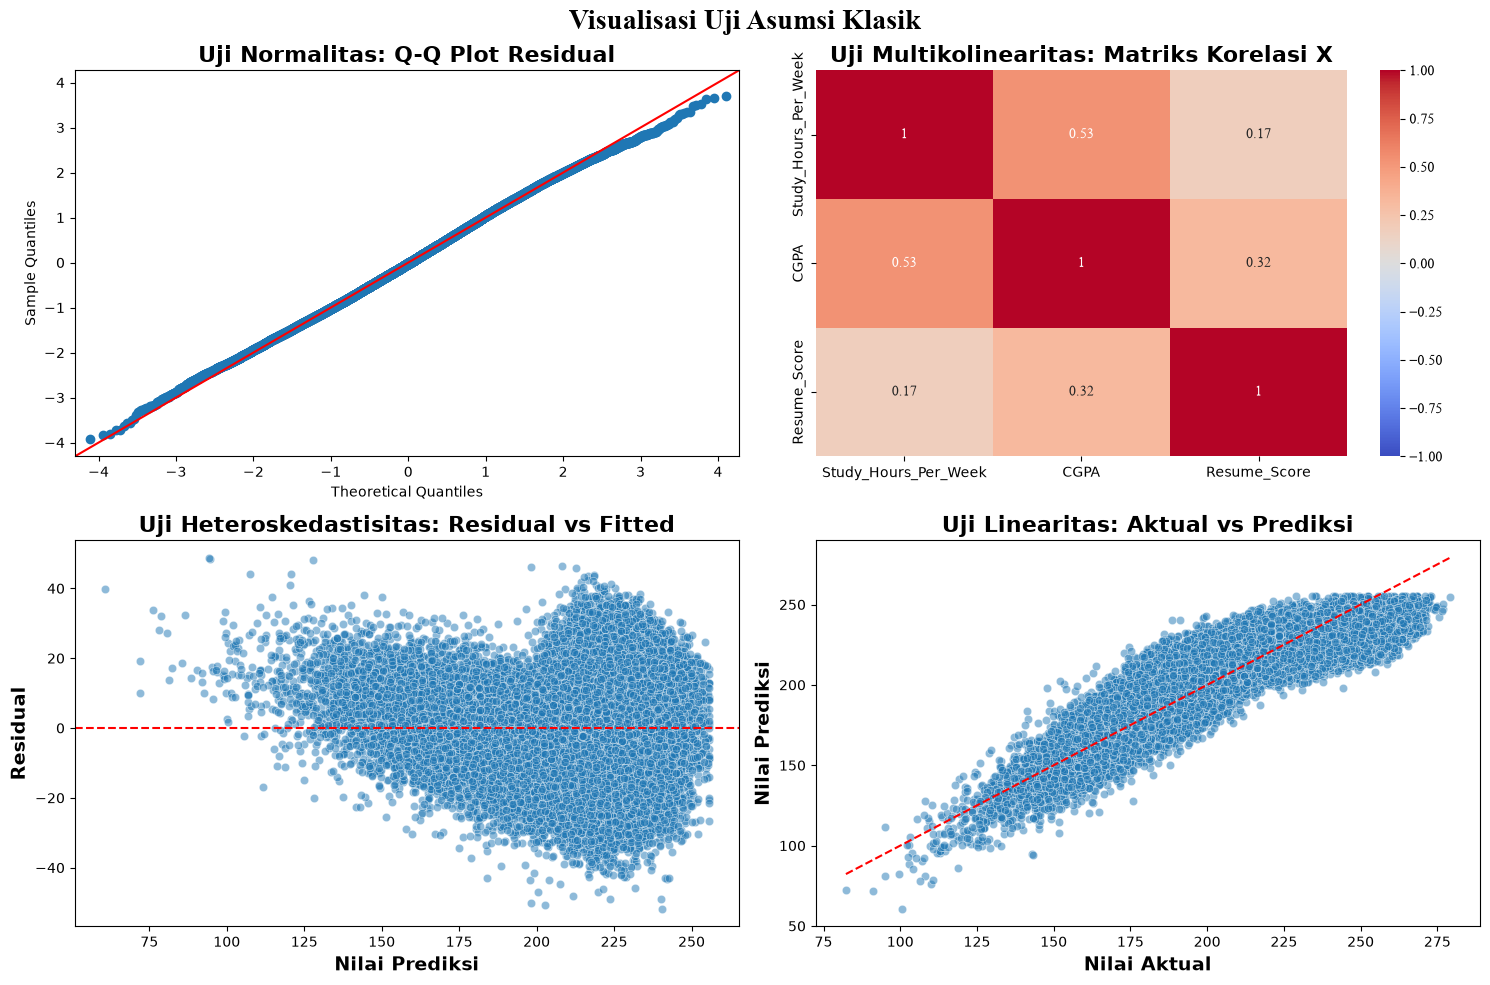

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.rcParams["font.family"] = "Times New Roman"
fig.suptitle('Visualisasi Uji Asumsi Klasik', fontsize=20, fontweight="bold")

# uji normalitas residual: Q-Q plot, Jarque-Bera
sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 0])
axes[0, 0].set_title('Uji Normalitas: Q-Q Plot Residual', fontsize=16, fontweight="bold")
jb_pval = model.pvalues.get('Jarque-Bera', 'N/A (Lihat summary untuk N besar)')
print(f"1. Uji normalitas")
print("Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.\n")

# 2. Uji multikolinearitas
print(f"2. Uji multikolinearitas")
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data[1:])
print("Syarat terpenuhi jika nilai VIF < 10.\n")
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', ax=axes[0, 1], vmin=-1, vmax=1)
axes[0, 1].set_title('Uji Multikolinearitas: Matriks Korelasi X', fontsize=16, fontweight="bold")

# Uji heteroskedastisitas: scatter plot, breusch-pagan)
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5, ax=axes[1, 0])
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel('Residual', fontsize=14, fontweight="bold")
axes[1, 0].set_title('Uji Heteroskedastisitas: Residual vs Fitted', fontsize=16, fontweight="bold")

_, pval_bp, _, _ = het_breuschpagan(residuals, X_const)
print(f"3. Uji heteroskedsatisitas")
print("Secara visual, pastikan titik-titik menyebar secara acak.\n")

# 4. Uji linearitas: scatter plot Aktual vs Prediksi
sns.scatterplot(x=Y, y=fitted_values, alpha=0.5, ax=axes[1, 1])
axes[1, 1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--')
axes[1, 1].set_xlabel('Nilai Aktual', fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 1].set_title('Uji Linearitas: Aktual vs Prediksi', fontsize=16, fontweight="bold")

print(f"4. Uji linearitas")
print("Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.\n")

plt.tight_layout()
plt.show()

# 3 Regresi

In [80]:
# 1. konversi ke array Numpy
Y_arr = Y.values
n_rows = len(Y_arr)

# bentuk matriks X
X_mat_list = [np.ones(n_rows)]
for col in features:
    X_mat_list.append(df[col].values)
    
X_arr = np.column_stack(X_mat_list)

# 2. bentuk normal equation: (X^T * X) * Beta = (X^T * Y) -> A * Beta = b
A = X_arr.T @ X_arr
b = X_arr.T @ Y_arr

print("Sistem persamaan linear")
print(f"Matriks A (X^T X) ordo {A.shape}:\n", np.round(A, 2))
print(f"\nVektor b (X^T Y) ordo {b.shape}:\n", np.round(b, 2))

# 3. fungsi dekomposisi LU (metode Doolittle)
def lu_decomposition(mat):
    n = len(mat)
    L = np.zeros((n, n))
    U = np.zeros((n, n))
    
    for i in range(n):
        # matriks U (upper)
        for k in range(i, n):
            sum_val = sum([L[i][j] * U[j][k] for j in range(i)])
            U[i][k] = mat[i][k] - sum_val
            
        # matriks L (lower)
        for k in range(i, n):
            if i == k:
                L[i][i] = 1 # Diagonal utama L wajib 1
            else:
                sum_val = sum([L[k][j] * U[j][i] for j in range(i)])
                L[k][i] = (mat[k][i] - sum_val) / U[i][i]
    return L, U

L_mat, U_mat = lu_decomposition(A)

# 4. fungsi substitusi
def forward_substitution(L, b):
    n = len(L)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - sum(L[i][j] * y[j] for j in range(i))
    return y

def backward_substitution(U, y):
    n = len(U)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - sum(U[i][j] * x[j] for j in range(i+1, n))) / U[i][i]
    return x

# 5. cari parameter (Beta)
y_vec = forward_substitution(L_mat, b)
beta_manual = backward_substitution(U_mat, y_vec)

# 6. hasil
print("\nParameter regresi (Lu-Gauss)")
print(f"Beta_0 (Intercept)\t\t: {beta_manual[0]:.6f}")
for i, feature in enumerate(features):
    print(f"Beta_{i+1} ({feature})\t: {beta_manual[i+1]:.6f}")

beta_numpy = np.linalg.solve(A, b)
error_max = np.max(np.abs(beta_manual - beta_numpy))
print(f"\nValidasi error (selisih dengan fungsi bawaan komputasi): {error_max:.15e}")

Sistem persamaan linear
Matriks A (X^T X) ordo (4, 4):
 [[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [1076408.0000 25605434.0000 3397354.6000 103808954.0000]
 [155302.1400 3397354.6000 486590.1900 14950574.2800]
 [4802287.0000 103808954.0000 14950574.2800 463926747.0000]]

Vektor b (X^T Y) ordo (4,):
 [10699569.7000 233311774.2000 33467500.3300 1035421243.3000]

Parameter regresi (Lu-Gauss)
Beta_0 (Intercept)		: -130.495659
Beta_1 (Study_Hours_Per_Week)	: 0.006624
Beta_2 (CGPA)	: 35.560423
Beta_3 (Resume_Score)	: 2.435217

Validasi error (selisih dengan fungsi bawaan komputasi): 1.534772309241816e-12


# 4 Manual

## 4.1 Matriks normal

In [81]:
n_data = len(df_clean)

# matriks X
X_matrix = np.column_stack((np.ones(n_data), df_clean[cols_x].values))

# vektor Y
Y_vector = df_clean[col_y].values

# matriks persamaan normal: A = X^T * X
A = np.dot(X_matrix.T, X_matrix)

# vektor hasil: b = X^T * Y
b = np.dot(X_matrix.T, Y_vector)

print("Matriks A:")
print(np.round(A, 2))
print("\nVektor b:")
print(np.round(b, 2))

Matriks A:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [1076408.0000 25605434.0000 3397354.6000 103808954.0000]
 [155302.1400 3397354.6000 486590.1900 14950574.2800]
 [4802287.0000 103808954.0000 14950574.2800 463926747.0000]]

Vektor b:
[10699569.7000 233311774.2000 33467500.3300 1035421243.3000]


## 4.2 Matriks dekomposisi LU

In [82]:
n = A.shape[0]

L = np.zeros((n, n))
U = np.zeros((n, n))

# algoritma Doolittle
for i in range(n):
    L[i][i] = 1.0
    
    # elemen matriks U
    for j in range(i, n):
        sum_upper = sum(L[i][k] * U[k][j] for k in range(i))
        U[i][j] = A[i][j] - sum_upper
        
    # elemen matriks L
    for j in range(i + 1, n):
        sum_lower = sum(L[j][k] * U[k][i] for k in range(i))
        L[j][i] = (A[j][i] - sum_lower) / U[i][i]

print("Matriks L:")
print(np.round(L, 4))
print("\nMatriks U:")
print(np.round(U, 4))

Matriks L:
[[1.0000 0.0000 0.0000 0.0000]
 [21.5282 1.0000 0.0000 0.0000]
 [3.1060 0.0222 1.0000 0.0000]
 [96.0457 0.1745 8.3007 1.0000]]

Matriks U:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [0.0000 2432350.3507 53985.2817 424551.0981]
 [0.0000 0.0000 3016.9134 25042.5367]
 [0.0000 0.0000 0.0000 2405564.7849]]


## 4.3 Hasil substitusi maju

In [83]:
y_vec = np.zeros(n)

# substitusi maju (dari atas ke bawah)
for i in range(n):
    sum_ly = sum(L[i][j] * y_vec[j] for j in range(i))
    y_vec[i] = b[i] - sum_ly

print("Vektor y:")
for i in range(n):
    print(f"y[{i}] = {y_vec[i]:.4f}")

Vektor y:
y[0] = 10699569.7000
y[1] = 2969725.7672
y[2] = 168266.7353
y[3] = 5858073.1407


## 4.4 Hasil substitusi mundur

In [84]:
# vektor koefisien a
a_vec = np.zeros(n)

# substitusi mundur (dari bawah ke atas)
for i in range(n - 1, -1, -1):
    sum_ua = sum(U[i][j] * a_vec[j] for j in range(i + 1, n))
    a_vec[i] = (y_vec[i] - sum_ua) / U[i][i]

print("Koefisien regresi:")
print(f"Intercept: \u03b2\u2080 = {a_vec[0]:.4f}")
print(f"Study Hours Per Week: \u03b2\u2081 = {a_vec[1]:.4f}")
print(f"CGPA: \u03b2\u2082 = {a_vec[2]:.4f}")
print(f"Interview Score: \u03b2\u2083 = {a_vec[3]:.4f}")

Koefisien regresi:
Intercept: β₀ = -130.4957
Study Hours Per Week: β₁ = 0.0066
CGPA: β₂ = 35.5604
Interview Score: β₃ = 2.4352


## 4.5 Model regresi linear berganda

In [85]:
print(f"Employability Score = {a_vec[0]:.2f} + ({a_vec[1]:.2f} * Study_Hours) + ({a_vec[2]:.2f} * CGPA) + ({a_vec[3]:.2f} * Interview_Score)")
print(f"Y = {a_vec[0]:.2f} + ({a_vec[1]:.2f} * X\u2081) + ({a_vec[2]:.2f} * X\u2082) + ({a_vec[3]:.2f} * X\u2083)")

Employability Score = -130.50 + (0.01 * Study_Hours) + (35.56 * CGPA) + (2.44 * Interview_Score)
Y = -130.50 + (0.01 * X₁) + (35.56 * X₂) + (2.44 * X₃)


# 5 Galat

In [86]:
# nilai eksak
exact_coeffs = np.linalg.solve(A, b)

# galat
errors = np.abs(exact_coeffs - a_vec)

param_names = [
    'Intercept (\u03b2\u2080)', 
    'Study_Hours_Per_Week (\u03b2\u2081)', 
    'CGPA (\u03b2\u2082)', 
    'Resume_Score (\u03b2\u2083)'
]

comparison_df = pd.DataFrame({
    'Parameter': param_names,
    'Nilai Eksak': exact_coeffs,
    'Nilai Estimasi': a_vec,
    'Galat Absolut': errors
})

pd.set_option('display.float_format', lambda x: '%.12f' % x)

print("Tabel Perbandingan Parameter dan Galat Metode LU-Gauss")
display(comparison_df)

Tabel Perbandingan Parameter dan Galat Metode LU-Gauss


,Parameter,Nilai Eksak,Nilai Estimasi,Galat Absolut
0,Intercept (β₀),-130.495659076497,-130.495659076501,0.000000000004
1,Study_Hours_Per_Week (β₁),0.006624099725,0.006624099725,0.000000000000
2,CGPA (β₂),35.560422528184,35.560422528184,0.000000000001
3,Resume_Score (β₃),2.435217366633,2.435217366633,0.000000000000
